### 1. Getting Setup

In [1]:
import torch 
import torchvision
print(f"Torch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Torch version: 2.11.0+cu128
TorchVision version: 0.26.0+cu128


In [2]:
import torch 
import torchvision
from torchvision import transforms
from torch import nn 
import matplotlib.pyplot as plt 

# try to import summary from torchinfo else if not found it will download and import 
try: 
    from torchinfo import summary
except:
    print(f"[INFO] Couldn't find summary...Downloading....")
    !pip install -q torchinfo
    from torchinfo import summary
    
""" try to import data_setup, engine from going_modular.going_modular 
else if not found it will clone github repository, then move pytorch/going_modular(all files)
into current working directory then it will remove pytorch file and import data_setup, engine
"""
try: 
    from going_modular.going_modular import data_setup, engine
except: 
    print(f"[INFO] Couldn't find going_modular...Downloading...")
    !git clone https://github.com/Abisheklimbu/pytorch
    !mv pytorch/going_modular . 
    !rm -rf pytorch 
    from going_modular.going_modular import data_setup, engine

[INFO] Couldn't find summary...Downloading....
[INFO] Couldn't find going_modular...Downloading...
Cloning into 'pytorch'...
remote: Enumerating objects: 2709, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 2709 (delta 5), reused 8 (delta 2), pack-reused 2691 (from 2)
Receiving objects: 100% (2709/2709), 318.45 MiB | 27.32 MiB/s, done.
Resolving deltas: 100% (264/264), done.
Updating files: 100% (3439/3439), done.


In [ ]:
# device agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# set up seeds 
def set_seed(seed:int = 42):
    # set manual_seed 
    torch.manual_seed(seed)
    
    # set cuda manual_seed
    torch.cuda.manual_seed(seed)

set_seed

<function __main__.set_seed(seed: int = 42)>

### 2. Get Data

In [5]:
from pathlib import Path 
import requests
import zipfile
import os 

def download_data(source: str, 
                  destination: str,
                  remove_source: bool = True) -> Path:
    """Downloads a zipped dataset from source and unzips to destination.

    Args:
        source (str): A link to a zipped file containing data.
        destination (str): A target directory to unzip data to.
        remove_source (bool): Whether to remove the source after downloading and extracting.
    
    Returns:
        pathlib.Path to downloaded data.
    
    Example usage:
        download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")
    """
    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it... 
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)
        
        # Download pizza, steak, sushi data
        target_file = Path(source).name
        with open(data_path / target_file, "wb") as f:
            request = requests.get(source)
            print(f"[INFO] Downloading {target_file} from {source}...")
            f.write(request.content)

        # Unzip pizza, steak, sushi data
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...") 
            zip_ref.extractall(image_path)

        # Remove .zip file
        if remove_source:
            os.remove(data_path / target_file)
    
    return image_path

In [6]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


PosixPath('data/pizza_steak_sushi')

In [ ]:
train_dir = image_path/"train"
test_dir = image_path/"test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 3. Get Dataset and DataLoader

In [ ]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [ ]:
from going_modular.going_modular import data_setup, engine

In [10]:
# Set the batch size
BATCH_SIZE = 32 

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7bb6e92a8380>,
 ['pizza', 'steak', 'sushi'])

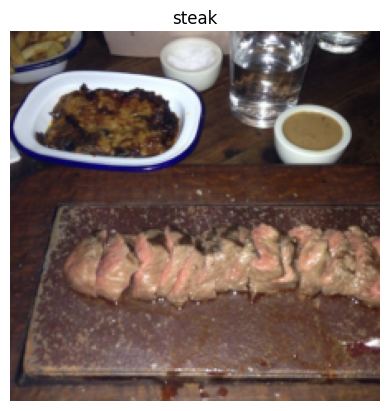

In [11]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

### 4. Replicating ViT Paper 

In [12]:
# Create example values
height = 224 
width = 224 
color_channels = 3 
patch_size = 16 

# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)
print(f"Number of patches (N) with image height (H={height}), width (W={width}) and patch size (P={patch_size}): {number_of_patches}")

Number of patches (N) with image height (H=224), width (W=224) and patch size (P=16): 196


In [13]:
# Input shape (this is the size of a single image)
embedding_layer_input_shape = (height, width, color_channels)

# Output shape
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output shape (single 2D image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2D image): (224, 224, 3)
Output shape (single 2D image flattened into patches): (196, 768)


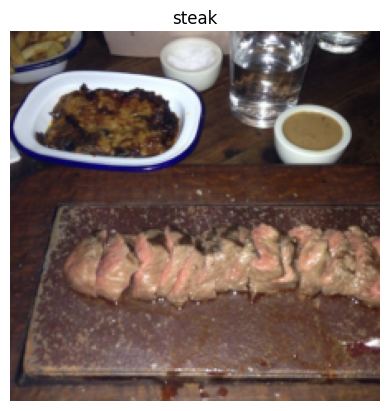

In [14]:
# Turning single image into patches 
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis("off");

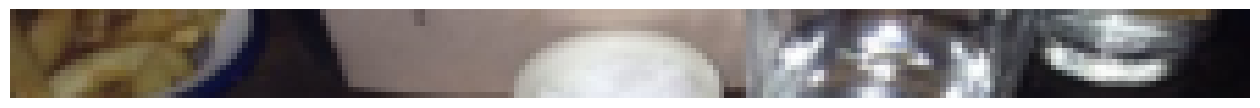

In [15]:
image_permuted = image.permute(1,2,0)
patch_size = 16 
plt.figure(figsize=(patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :])
plt.axis(False);


Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


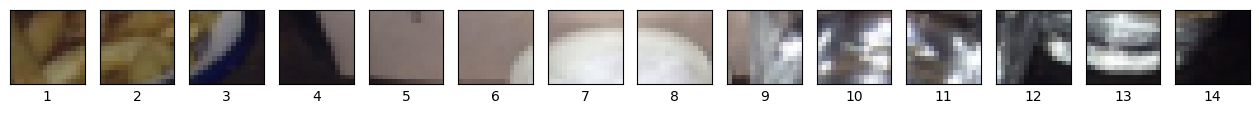

In [16]:
# Patches for top row of image 
img_size = 224
patch_size = 16
num_patches = img_size / patch_size
assert img_size % patch_size == 0

print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

fig, ax = plt.subplots(nrows=1, 
                       ncols=img_size//patch_size, 
                       figsize=(patch_size, patch_size), 
                       sharex=True, 
                       sharey=True)

for i,patch in enumerate(range(0, img_size, patch_size)):
    ax[i].imshow(image_permuted[:patch_size, patch:patch + patch_size, :])
    ax[i].set_xlabel(i+1)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

Number of patches per row: 14.0
Total patches: 196.0
Patch size: 16 pixels x 16 pixels


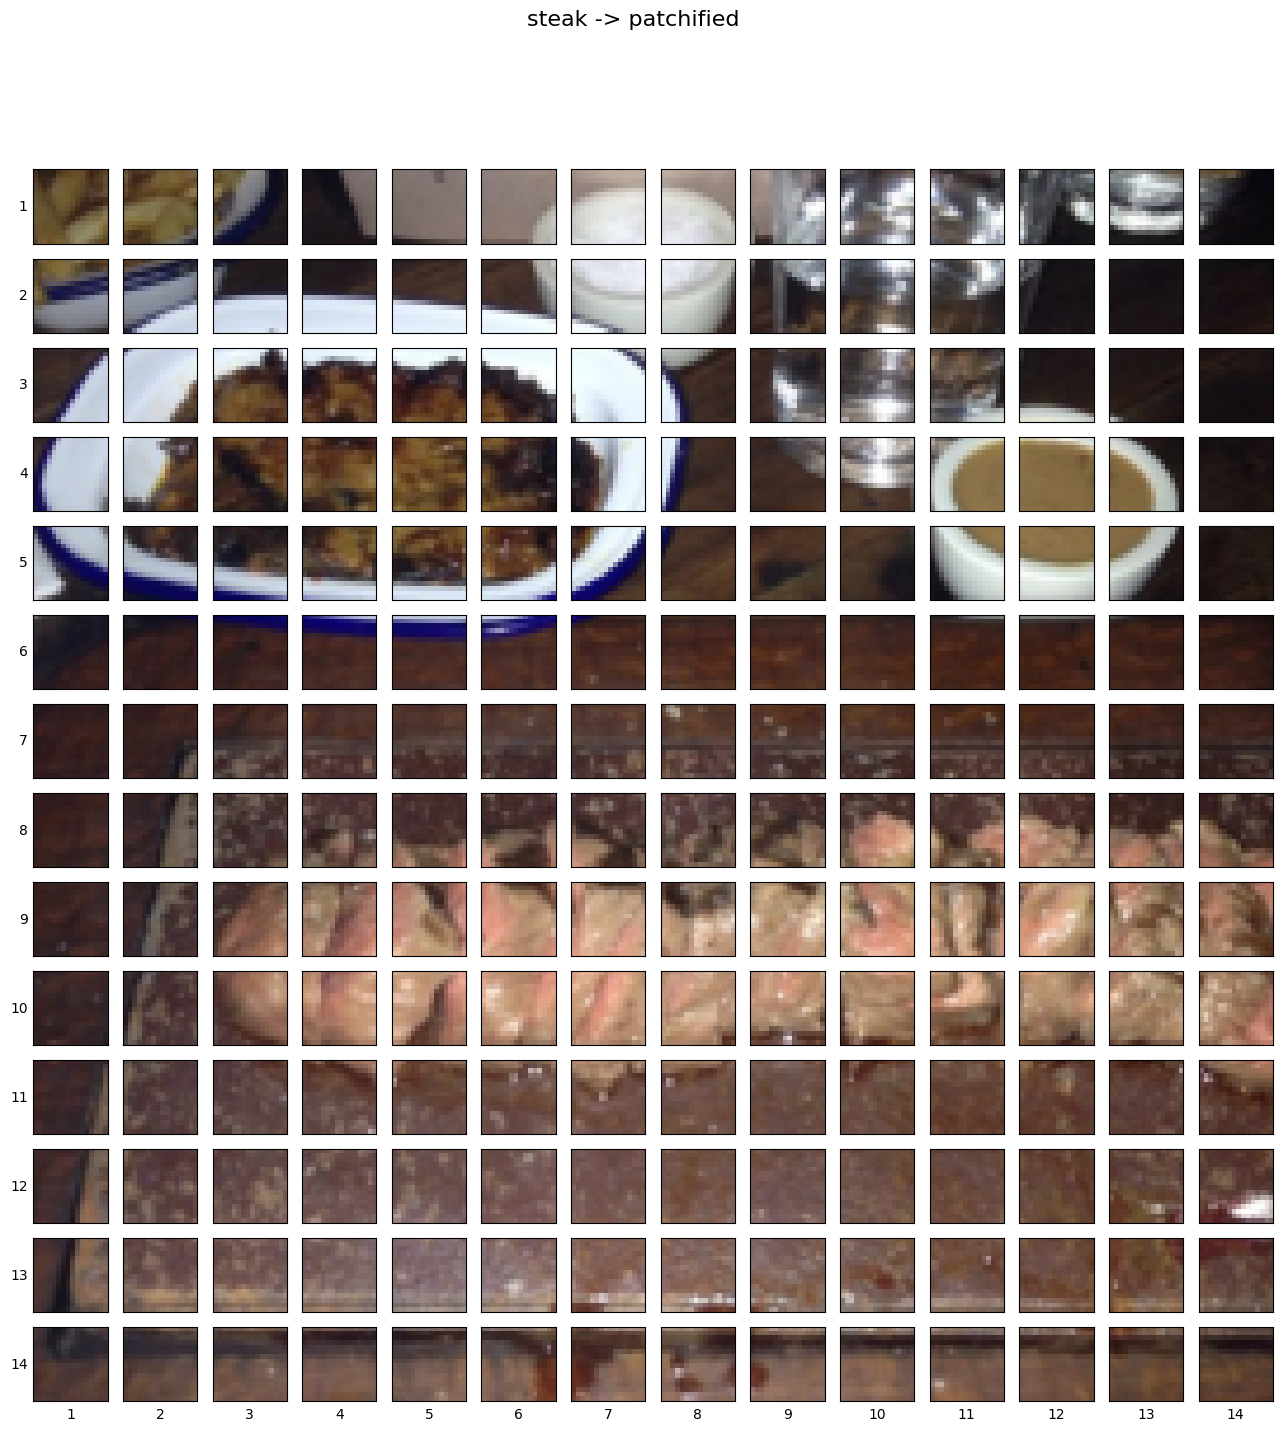

In [17]:
# Patches for whole image 
img_size = 224
patch_size = 16
num_patches = img_size / patch_size
assert img_size % patch_size == 0

print(f"Number of patches per row: {num_patches}\nTotal patches: {num_patches*num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

fig, ax = plt.subplots(nrows=img_size//patch_size,  
                       ncols=img_size//patch_size, 
                       figsize=(patch_size, patch_size), 
                       sharex=True, 
                       sharey=True)

for i,patch_height in enumerate(range(0, img_size, patch_size)):
    for j,patch_width in enumerate(range(0, img_size, patch_size)):
        ax[i,j].imshow(image_permuted[patch_height:patch_height+patch_size, patch_width:patch_width+patch_size, :])
        ax[i,j].set_ylabel(i+1, rotation="horizontal", horizontalalignment="right", verticalalignment="center")
        ax[i,j].set_xlabel(j+1)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
        ax[i,j].label_outer()
        
fig.suptitle(f"{class_names[label]} -> patchified", fontsize=16)
plt.show()
    

#### CREATING IMAGE PATCHES WITH torch.nn.Conv2d()

In [18]:
from torch import nn
patch_size = 16 
conv2d = nn.Conv2d(
    in_channels=3, 
    out_channels=768, 
    kernel_size=patch_size, 
    stride=patch_size, 
    padding=0
)

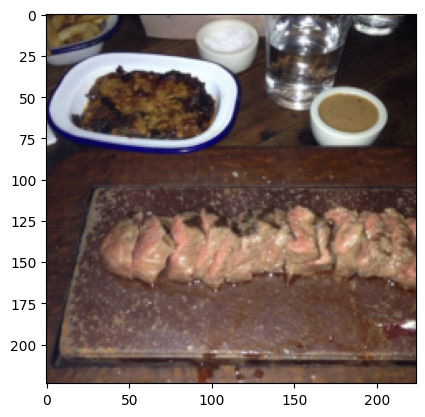

In [19]:
plt.imshow(image_permuted)

In [20]:
img_out_of_conv2d = conv2d(image.unsqueeze(0))
print(img_out_of_conv2d.shape)

torch.Size([1, 768, 14, 14])


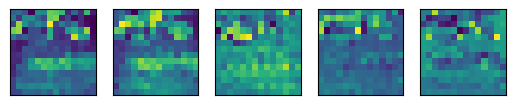

In [21]:
# plotting random 5 convolutional feature maps 
import random 
random_idx = random.sample(range(0,768), k=5)
fig, ax = plt.subplots(nrows=1, 
                       ncols=5)

for i, idx in enumerate(random_idx):
    img_conv_feature_map = img_out_of_conv2d[:, idx, :, :]
    ax[i].imshow(img_conv_feature_map.squeeze().detach().numpy())
    ax[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

In [22]:
# Get single feature map in tensor form 
single_feature_map = img_out_of_conv2d[:,0,:,:]
single_feature_map, single_feature_map.requires_grad

(tensor([[[0.2303, 0.2217, 0.1666, 0.1532, 0.3251, 0.3690, 0.6008, 0.4573,
           0.4637, 0.4682, 0.2653, 0.0944, 0.4370, 0.0256],
          [0.2001, 0.5117, 0.2212, 0.2704, 0.4180, 0.3781, 0.5311, 0.3353,
           0.3118, 0.3683, 0.3132, 0.0751, 0.0771, 0.0719],
          [0.3966, 0.4606, 0.1302, 0.2983, 0.2312, 0.2837, 0.7419, 0.0694,
           0.3979, 0.5862, 0.3603, 0.1234, 0.0939, 0.0564],
          [0.6344, 0.2686, 0.0751, 0.0835, 0.1130, 0.0875, 0.6627, 0.0686,
           0.2022, 0.3316, 0.2834, 0.2476, 0.4011, 0.0691],
          [0.0330, 0.2158, 0.4449, 0.3514, 0.1960, 0.3618, 0.2320, 0.1573,
           0.1216, 0.0713, 0.5656, 0.3419, 0.1196, 0.0816],
          [0.0905, 0.1299, 0.1780, 0.2064, 0.2370, 0.2726, 0.1208, 0.1109,
           0.1240, 0.1047, 0.1273, 0.1080, 0.0730, 0.0834],
          [0.1160, 0.1036, 0.1097, 0.1433, 0.1241, 0.1220, 0.1820, 0.1869,
           0.0921, 0.1399, 0.1256, 0.1311, 0.1300, 0.1295],
          [0.1085, 0.2471, 0.1090, 0.1998, 0.2029, 0.10

In [23]:
single_feature_map.shape

torch.Size([1, 14, 14])

#### FLATTENING THE PATCH EMBEDDINGS WITH torch.nn.Flatten()

In [26]:
flatten = nn.Flatten(start_dim=2, # feature_map_height
                     end_dim=3) # feature_map_width
                     

torch.Size([3, 224, 224])


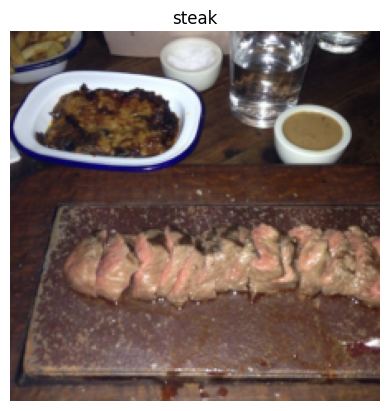

In [27]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
print(image.shape)
plt.axis("off");

In [29]:
img_out_of_conv = conv2d(image.unsqueeze(0))
img_out_of_conv.shape

torch.Size([1, 768, 14, 14])

In [30]:
img_out_of_flattened = flatten(img_out_of_conv)
img_out_of_flattened.shape

torch.Size([1, 768, 196])

In [31]:
img_out_of_conv_flattened_reshaped = img_out_of_flattened.permute(0,2,1)
img_out_of_conv_flattened_reshaped.shape

torch.Size([1, 196, 768])

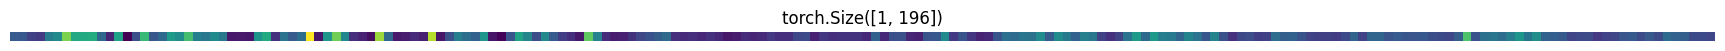

In [32]:
single_flattened_feature_map = img_out_of_conv_flattened_reshaped[:, :, 0]
plt.figure(figsize=(22,22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(single_flattened_feature_map.shape)
plt.axis("off");

In [33]:
single_flattened_feature_map, single_flattened_feature_map.requires_grad

(tensor([[0.2303, 0.2217, 0.1666, 0.1532, 0.3251, 0.3690, 0.6008, 0.4573, 0.4637,
          0.4682, 0.2653, 0.0944, 0.4370, 0.0256, 0.2001, 0.5117, 0.2212, 0.2704,
          0.4180, 0.3781, 0.5311, 0.3353, 0.3118, 0.3683, 0.3132, 0.0751, 0.0771,
          0.0719, 0.3966, 0.4606, 0.1302, 0.2983, 0.2312, 0.2837, 0.7419, 0.0694,
          0.3979, 0.5862, 0.3603, 0.1234, 0.0939, 0.0564, 0.6344, 0.2686, 0.0751,
          0.0835, 0.1130, 0.0875, 0.6627, 0.0686, 0.2022, 0.3316, 0.2834, 0.2476,
          0.4011, 0.0691, 0.0330, 0.2158, 0.4449, 0.3514, 0.1960, 0.3618, 0.2320,
          0.1573, 0.1216, 0.0713, 0.5656, 0.3419, 0.1196, 0.0816, 0.0905, 0.1299,
          0.1780, 0.2064, 0.2370, 0.2726, 0.1208, 0.1109, 0.1240, 0.1047, 0.1273,
          0.1080, 0.0730, 0.0834, 0.1160, 0.1036, 0.1097, 0.1433, 0.1241, 0.1220,
          0.1820, 0.1869, 0.0921, 0.1399, 0.1256, 0.1311, 0.1300, 0.1295, 0.1085,
          0.2471, 0.1090, 0.1998, 0.2029, 0.1036, 0.0911, 0.2090, 0.2187, 0.3686,
          0.1477

#### TURNING ViT PATCH EMBEDDINGS LAYER INTO PYTORCH MODULE 